In [1]:
#!/usr/bin/env python
# coding: utf-8

# =============================================================================
# 导入库，设置绘图参数，加载数据
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

Path('figures/feature_importance').mkdir(parents=True, exist_ok=True)

sns.set_context("paper")
sns.set_palette('muted')

ss   = 10
sss  = 8
ssss = 6

matplotlib.rcParams['figure.dpi']           = 600
matplotlib.rcParams['font.sans-serif']      = ['Arial']
matplotlib.rcParams['font.family']          = 'sans-serif'
matplotlib.rcParams['font.style']           = 'normal'
matplotlib.rcParams['font.weight']          = 'bold'
matplotlib.rcParams["axes.labelweight"]     = "bold"
matplotlib.rcParams['axes.titlesize']       = sss
matplotlib.rcParams['legend.fontsize']      = ss
matplotlib.rcParams['axes.labelsize']       = ss
matplotlib.rcParams['xtick.labelsize']      = ss
matplotlib.rcParams['ytick.labelsize']      = ss
matplotlib.rcParams['axes.linewidth']       = 0.6
matplotlib.rcParams['axes.grid']            = False

# 加载RFE数据
df_scores = pd.read_csv('results/rfe/rfe_scores.csv')

with open('results/rfe/rfe_features.json', 'r') as f:
    features_data = json.load(f)

with open('results/rfe/optimal_features.json', 'r') as f:
    optimal_data = json.load(f)

# 提取关键变量
n_original        = optimal_data['original_n_features']
n_optimal         = optimal_data['optimal_n_features']
selected_features = optimal_data['selected_features']
removed_features  = optimal_data['removed_features']

all_features_rmse = optimal_data['all_features_score']['rmse_mean']
all_features_mae  = optimal_data['all_features_score']['mae_mean']
optimal_rmse      = optimal_data['optimal_score']['rmse_mean']
optimal_mae       = optimal_data['optimal_score']['mae_mean']
relative_change_rmse = optimal_data['optimal_score']['relative_change_rmse_pct']
relative_change_mae  = optimal_data['optimal_score']['relative_change_mae_pct']

# 按特征数量升序排列
n_features = df_scores['n_features'].values[::-1]
rmse_mean  = df_scores['cv_rmse_mean'].values[::-1]
rmse_std   = df_scores['cv_rmse_std'].values[::-1]
mae_mean   = df_scores['cv_mae_mean'].values[::-1]
mae_std    = df_scores['cv_mae_std'].values[::-1]

# 绘图配色
line_color   = '#2e7d32'
marker_fill  = '#a5d6a7'
marker_edge  = '#1b5e20'




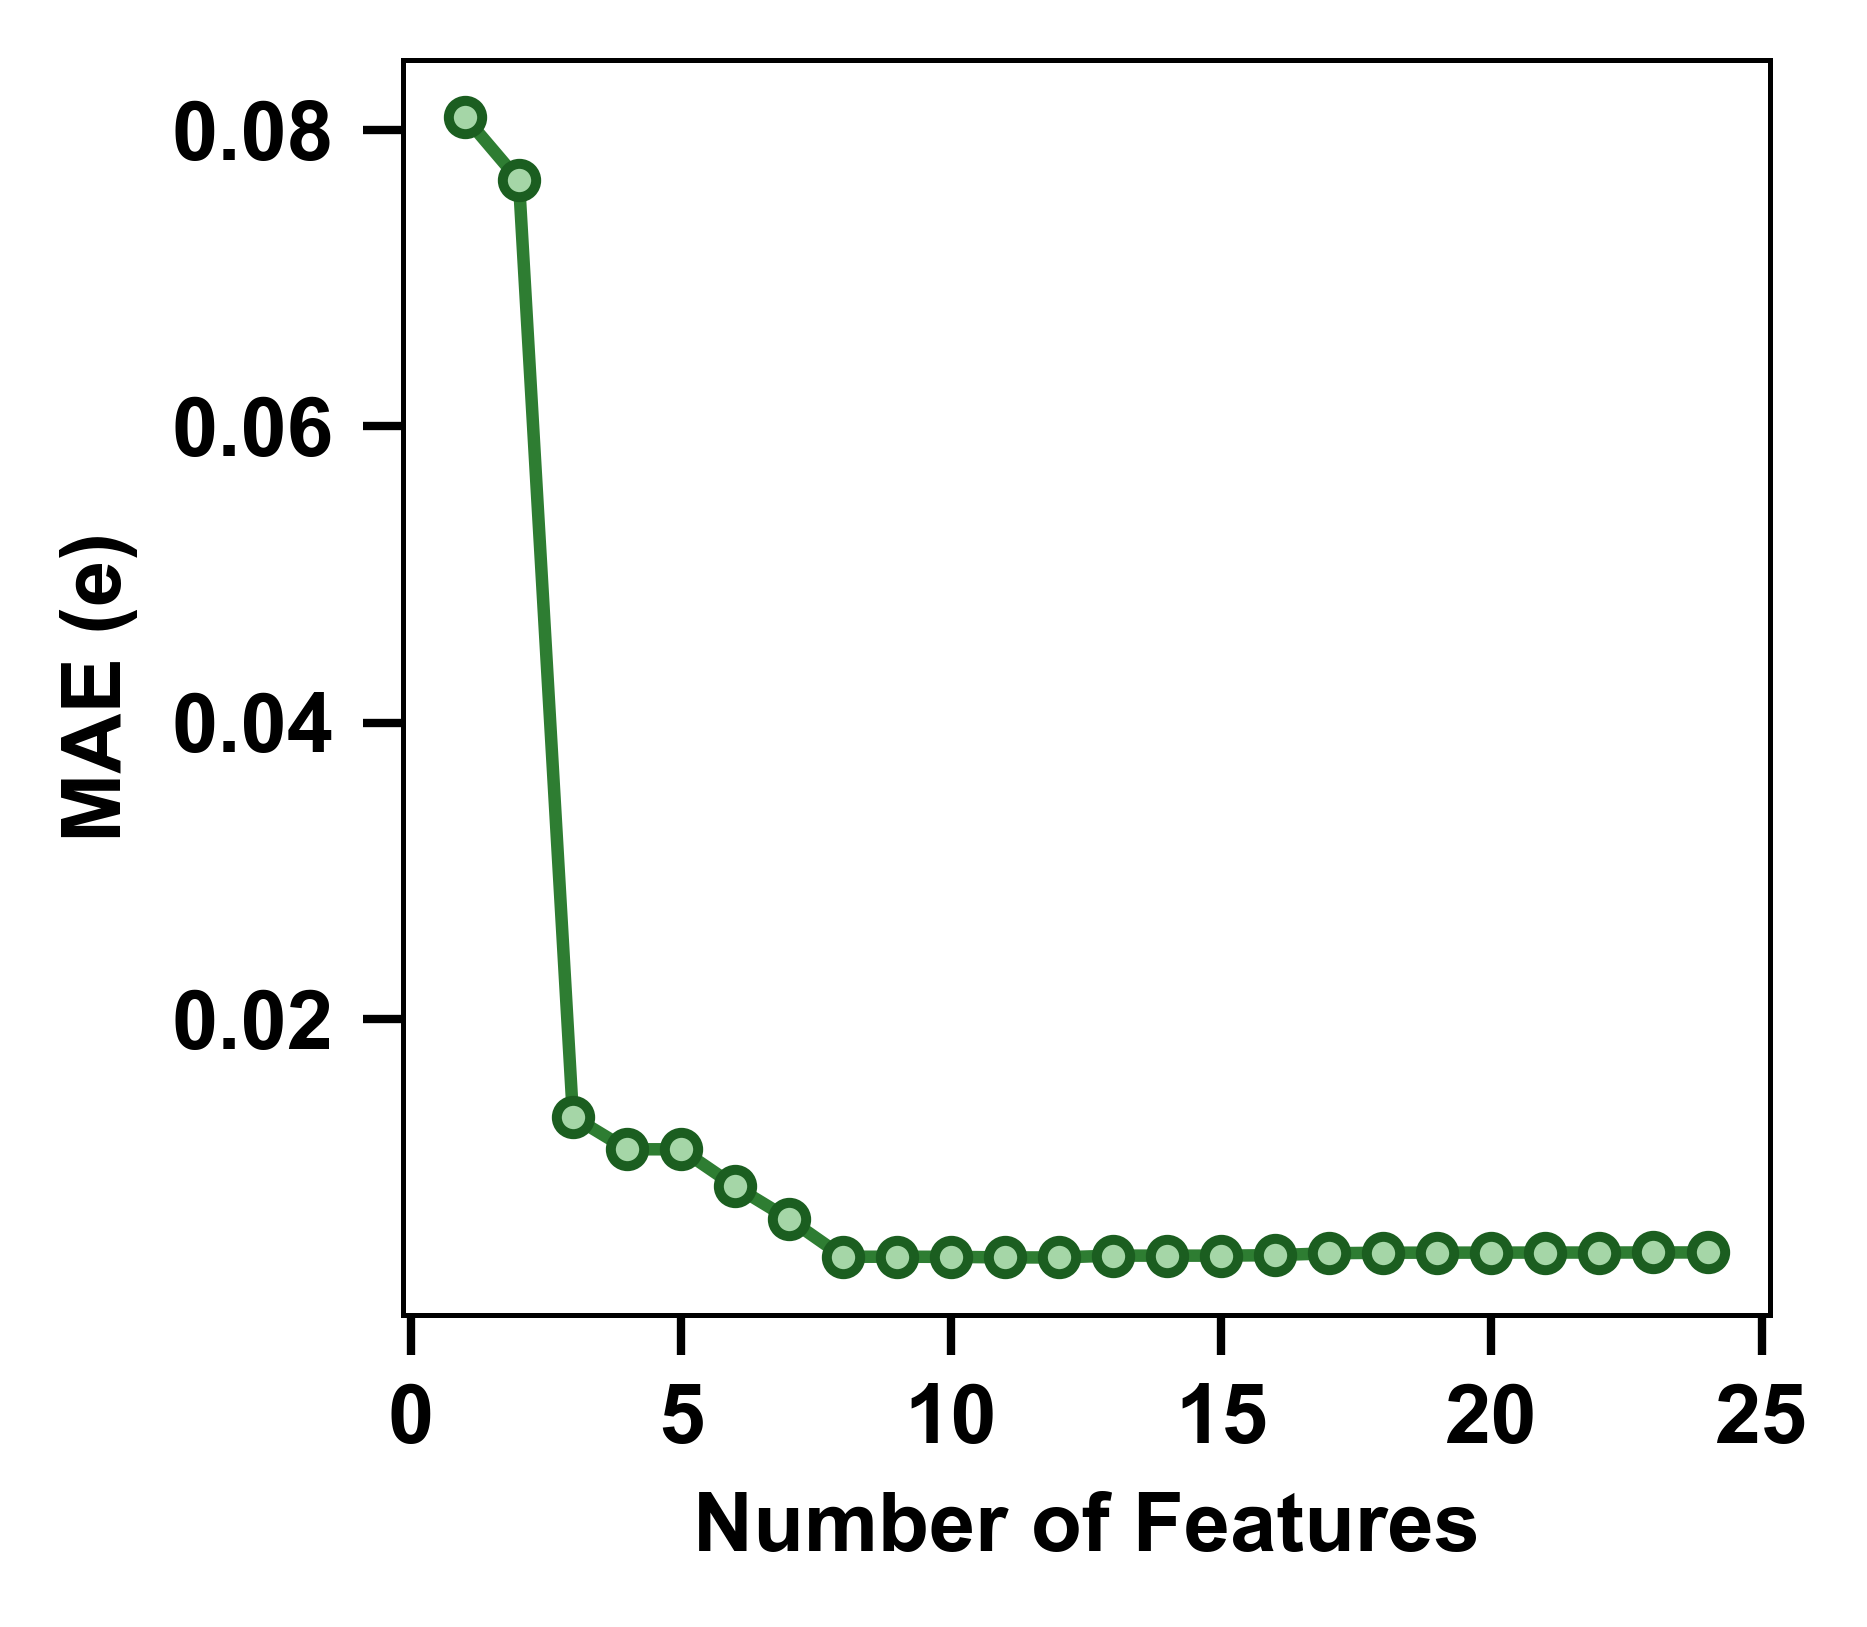

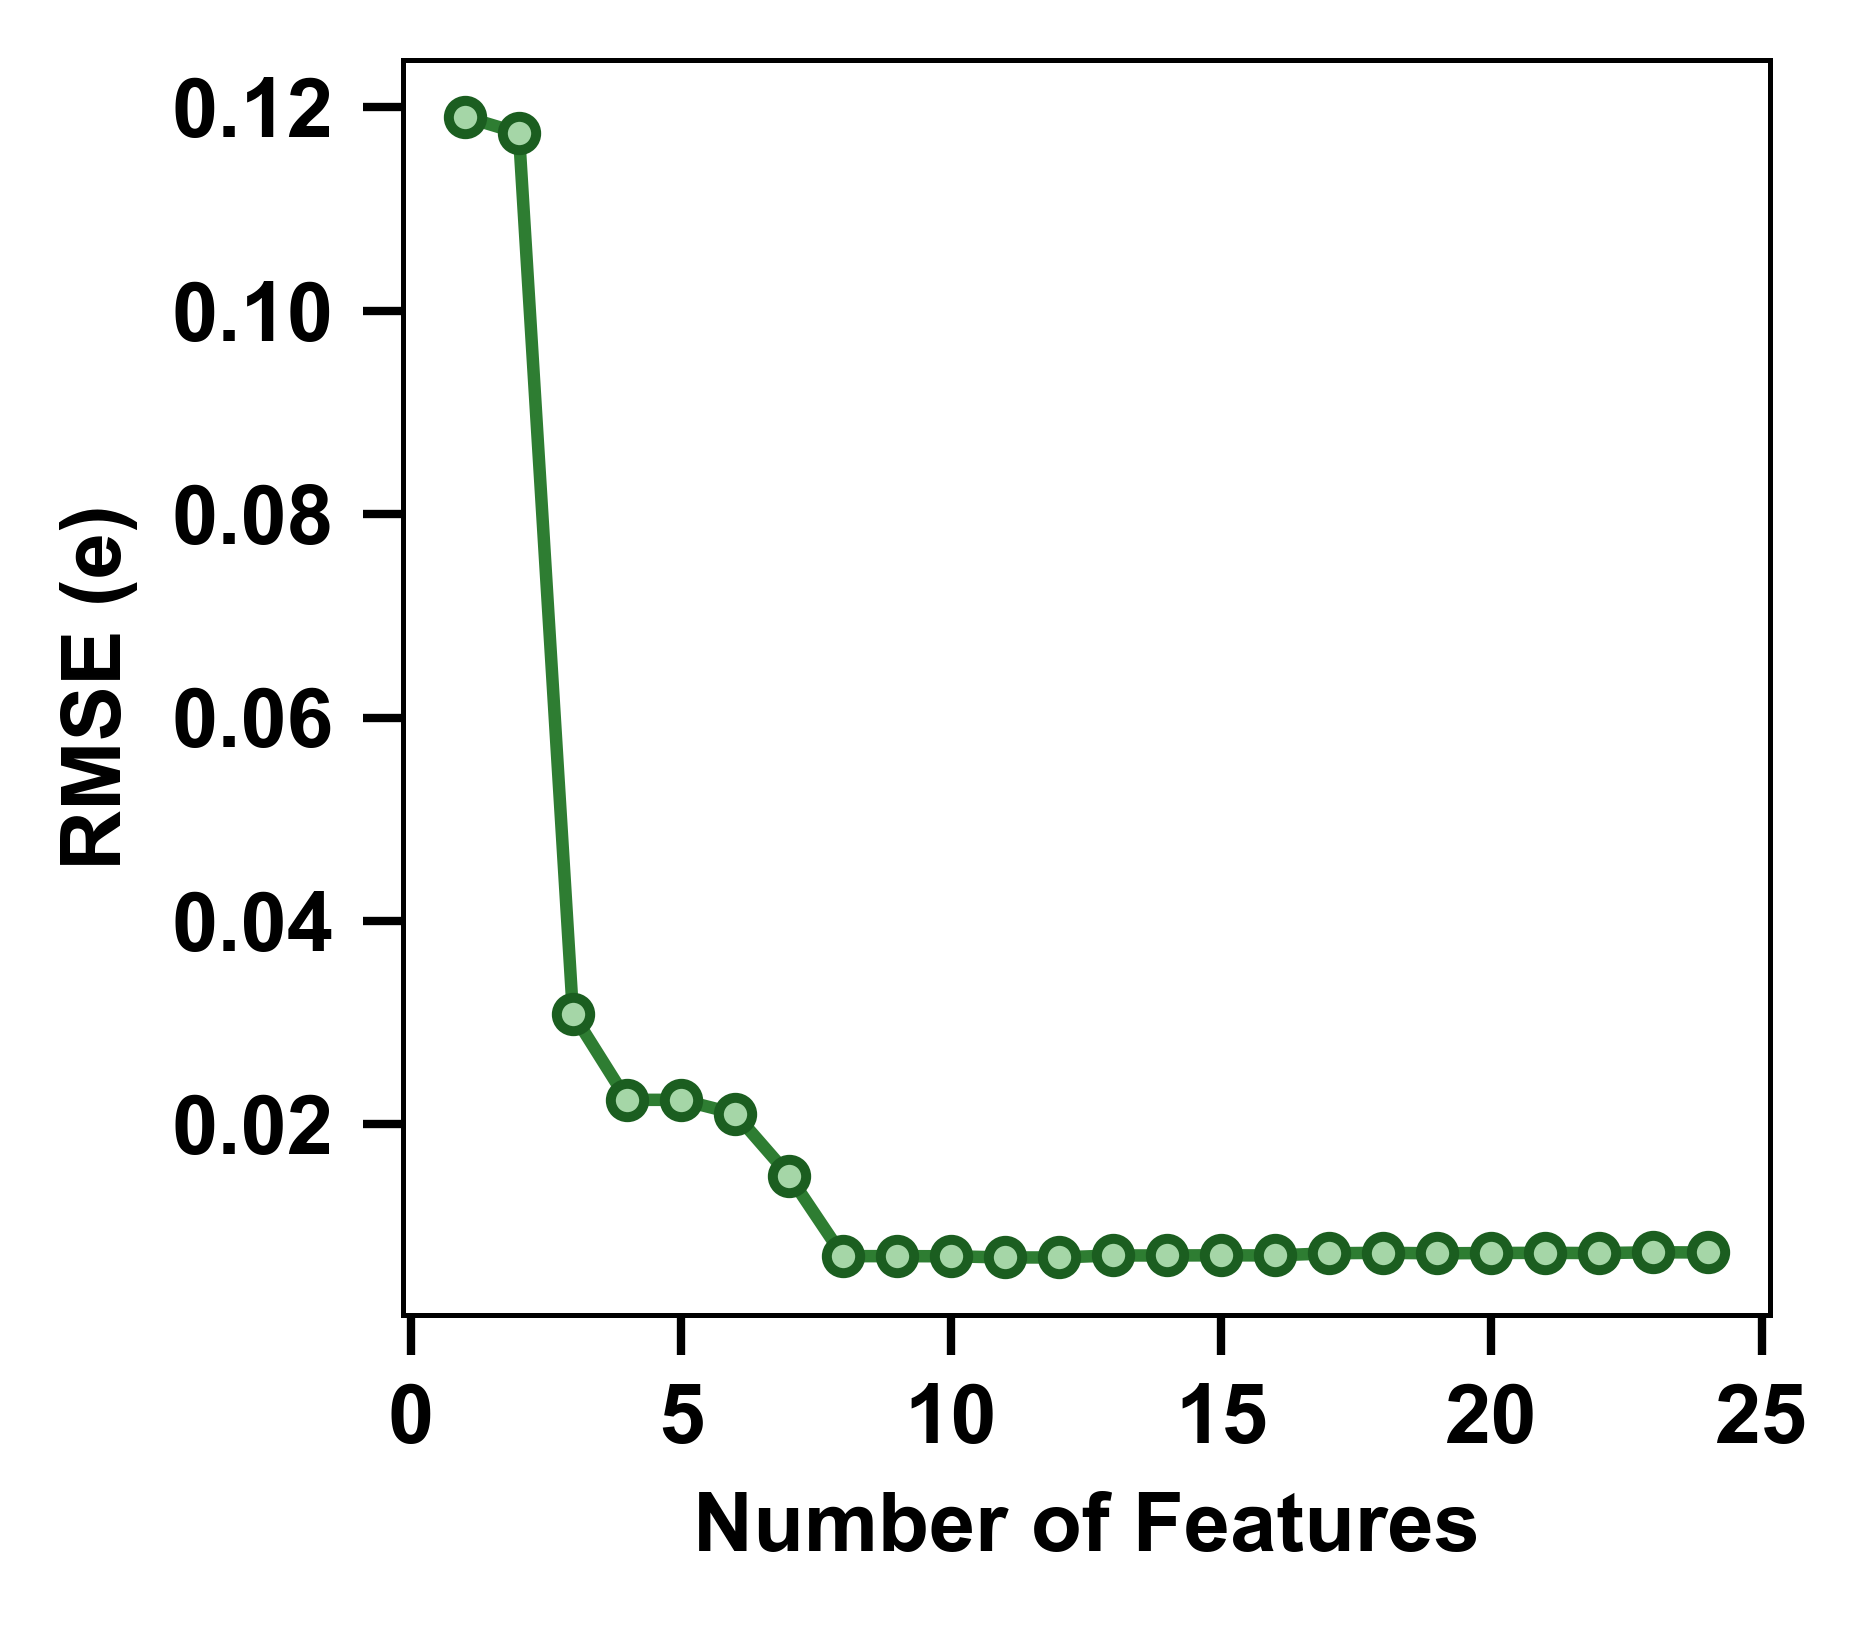

In [3]:
# =============================================================================
# MAE曲线与RMSE曲线（论文用图）
# =============================================================================

# MAE曲线
fig, ax = plt.subplots(figsize=(3.2, 2.8))

ax.plot(n_features, mae_mean,
        marker='o', linestyle='-', linewidth=1.5, markersize=4,
        color=line_color,
        markerfacecolor=marker_fill,
        markeredgecolor=marker_edge,
        markeredgewidth=1.2)

ax.set_xlabel('Number of Features', fontsize=ss, weight='bold')
ax.set_ylabel('MAE (e)',            fontsize=ss, weight='bold')
ax.xaxis.set_major_locator(MultipleLocator(5))

plt.tight_layout()
plt.savefig('figures/feature_importance/rfe_mae.png', dpi=600, bbox_inches='tight')
plt.savefig('figures/feature_importance/rfe_mae.pdf', dpi=600, bbox_inches='tight')
plt.show()

# RMSE曲线
fig, ax = plt.subplots(figsize=(3.2, 2.8))

ax.plot(n_features, rmse_mean,
        marker='o', linestyle='-', linewidth=1.5, markersize=4,
        color=line_color,
        markerfacecolor=marker_fill,
        markeredgecolor=marker_edge,
        markeredgewidth=1.2)

ax.set_xlabel('Number of Features', fontsize=ss, weight='bold')
ax.set_ylabel('RMSE (e)',            fontsize=ss, weight='bold')
ax.xaxis.set_major_locator(MultipleLocator(5))

plt.tight_layout()
plt.savefig('figures/feature_importance/rfe_rmse.png', dpi=600, bbox_inches='tight')
plt.savefig('figures/feature_importance/rfe_rmse.pdf', dpi=600, bbox_inches='tight')
plt.show()




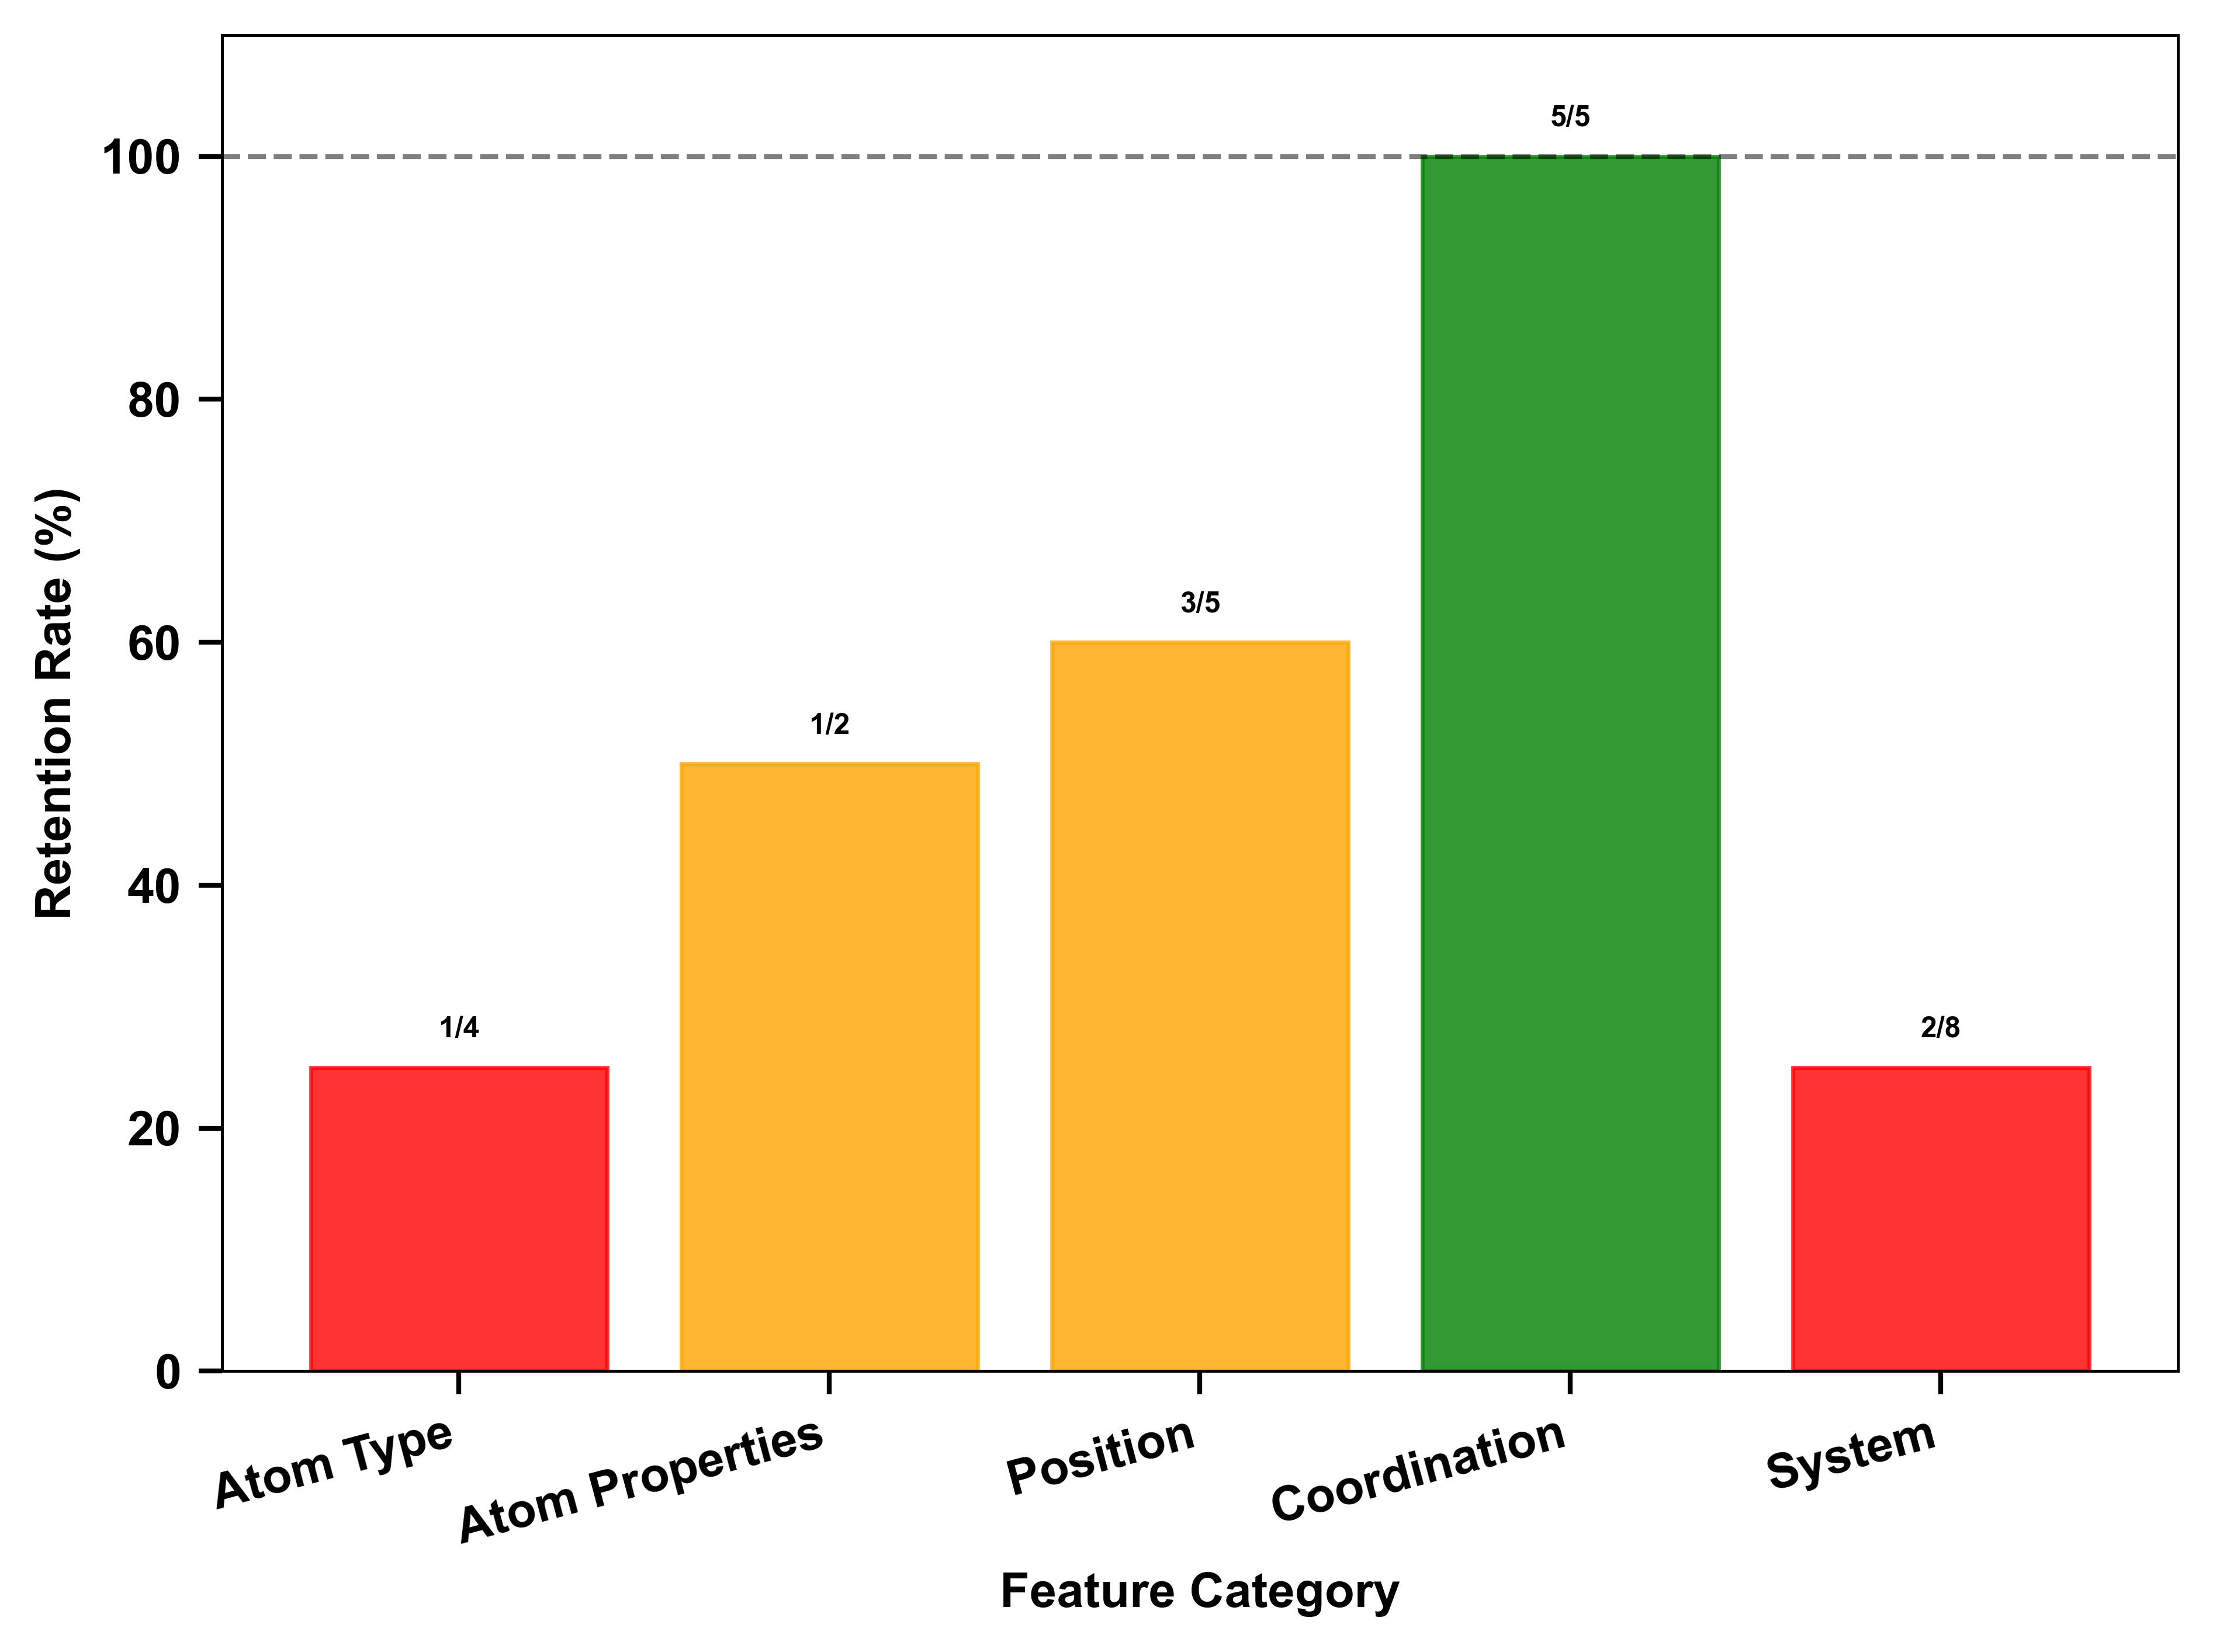

In [4]:
# =============================================================================
# 各特征类别保留情况统计与柱状图
# =============================================================================

feature_groups = {
    'Atom Type':       ['T_O', 'T_C', 'T_Ti1', 'T_Ti2'],
    'Atom Properties': ['Rad', 'EN'],
    'Position':        ['Layer', 'D_E', 'D_C', 'D_M1', 'D_M2'],
    'Coordination':    ['N_O', 'N_C', 'N_Ti1', 'N_Ti2', 'M_Inf'],
    'System':          ['SC_a', 'SC_b', 'H_A', 'H_P', 'AR', 'H_Dens', 'Sides', 'Del']
}

category_stats = []
for category, features in feature_groups.items():
    cat_feats  = [f for f in features if f in optimal_data['original_features']]
    n_total    = len(cat_feats)
    n_selected = len([f for f in cat_feats if f in selected_features])
    category_stats.append({
        'Category':       category,
        'Total':          n_total,
        'Selected':       n_selected,
        'Removed':        n_total - n_selected,
        'Retention_Rate': n_selected / n_total * 100 if n_total > 0 else 0
    })

df_category_stats = pd.DataFrame(category_stats)
df_category_stats.to_csv('results/rfe/rfe_category_stats.csv', index=False)

# 柱状图
fig, ax = plt.subplots(figsize=(6.4, 4.8))

bars   = ax.bar(df_category_stats['Category'], df_category_stats['Retention_Rate'], alpha=0.8)
colors = ['green' if r == 100 else 'orange' if r >= 50 else 'red'
          for r in df_category_stats['Retention_Rate']]
for bar, color in zip(bars, colors):
    bar.set_color(color)

for i, row in df_category_stats.iterrows():
    ax.text(i, row['Retention_Rate'] + 2,
            f"{int(row['Selected'])}/{int(row['Total'])}",
            ha='center', va='bottom', fontsize=ssss, weight='bold')

ax.set_xlabel('Feature Category',   fontsize=ss, weight='bold')
ax.set_ylabel('Retention Rate (%)', fontsize=ss, weight='bold')
ax.set_xticklabels(df_category_stats['Category'], rotation=15, ha='right')
ax.axhline(100, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_ylim(0, 110)

plt.tight_layout()
plt.savefig('figures/feature_importance/rfe_category_retention.png', dpi=600, bbox_inches='tight')
plt.show()